# Creación del modelo

### Cargando librerias 


In [91]:
import pandas as pd 
import numpy as np 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, confusion_matrix, average_precision_score
import matplotlib.pyplot as plt

## Cargando dataset

In [92]:
df = pd.read_csv("data_clean.csv")

## Codificar categorías

In [93]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].astype(str)
    df[col] = LabelEncoder().fit_transform(df[col])

In [94]:
for col in df.select_dtypes(include='float64'):
    df[col] = df[col].astype('float32')

for col in df.select_dtypes(include='int64'):
    df[col] = df[col].astype('int32')

### Features y Target

In [95]:
X = df.drop(columns=["isFraud", "TransactionID"])
y= df["isFraud"]

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [97]:
X_train = X_train.sample(frac=0.3, random_state=42)
y_train = y_train.loc[X_train.index]

In [98]:
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8],
    "colsample_bytree": [0.7, 0.8],
    "min_child_weight": [1, 5],
    "gamma": [0, 1]
}

In [99]:
model = XGBClassifier(
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
    eval_metric='aucpr'
)

In [100]:
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=10,
    scoring="average_precision",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [101]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8], 'gamma': [0, 1], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], ...}"
,n_iter,10
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


#### Ajustar el threshold

In [102]:
y_proba = random_search.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

In [103]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)

best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

In [104]:
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred = (y_proba > t).astype(int)
    print(f"\nThreshold {t}")
    print(classification_report(y_test, y_pred))



Threshold 0.3
              precision    recall  f1-score   support

           0       0.99      0.98      0.99    113975
           1       0.63      0.71      0.67      4133

    accuracy                           0.98    118108
   macro avg       0.81      0.85      0.83    118108
weighted avg       0.98      0.98      0.98    118108


Threshold 0.4
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    113975
           1       0.71      0.67      0.69      4133

    accuracy                           0.98    118108
   macro avg       0.85      0.83      0.84    118108
weighted avg       0.98      0.98      0.98    118108


Threshold 0.5
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    113975
           1       0.78      0.64      0.70      4133

    accuracy                           0.98    118108
   macro avg       0.88      0.82      0.85    118108
weighted avg       0.98      

In [108]:
threshold = 0.5
y_pred = (y_proba > threshold).astype(int)

Detectas el 64% de los fraudes  
y casi 8 de cada 10 alertas son correctas

##### Las variables importantes

In [109]:
feat_imp = pd.Series(random_search.best_estimator_.feature_importances_, index=X.columns
).sort_values(ascending=False)
feat_imp.head(15)

V258     0.177246
V70      0.061412
V91      0.055902
V201     0.046858
V29      0.030288
V294     0.016456
V200     0.008584
C14      0.007921
id_35    0.007401
V317     0.006565
id_17    0.005988
C8       0.005890
V268     0.005822
C3       0.005653
V287     0.005463
dtype: float32

In [111]:
#feat_imp.head(10).plot(kind='barh')

#### Confusion Matrix

In [113]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[113213    762]
 [  1470   2663]]


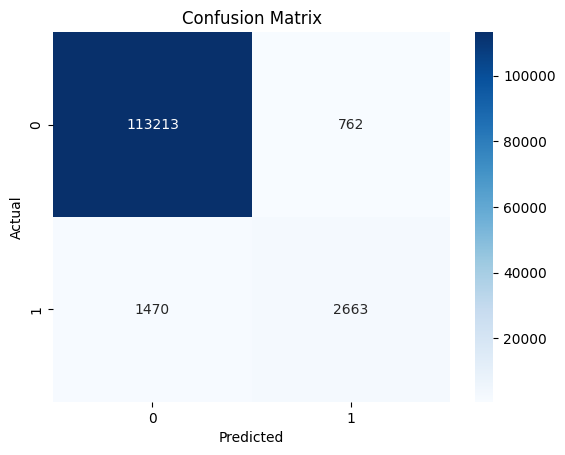

In [114]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

TP = 2663 - > fraudes detectados\
FN = 1470 -> fraudes no detectados -> crítico!!!\
FP = 762 -> falsas alertas\
VN = 113223\

### Calculando PR-AUC 

mide que tan bien detestamos los fraudes realmente
- Cuántos fraudes detecto? recall 
- Cuántos acierto? precision 

In [ ]:
pr_auc = average_precision_score(y_test, y_proba)

PR-AUC: 0.7341895931584165


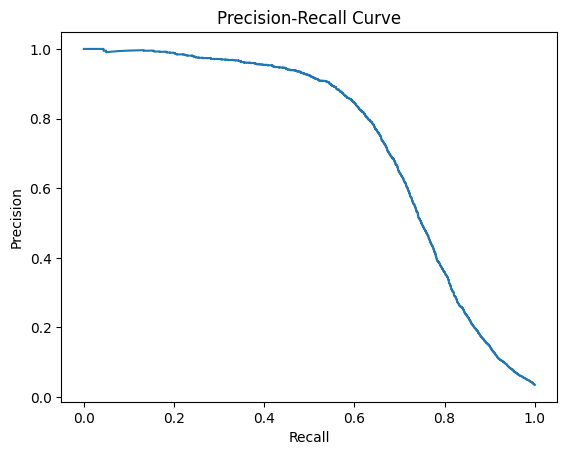

In [116]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

PR-AUC -> mide que tan bien detecto los fraudes -> solo me importa fruade\
ROC-AUC -> mode que tan bien se separan en general fraude vs no fraude 

In [ ]:
print("PR-AUC:", pr_auc)
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

PR-AUC: 0.7341895931584165
ROC-AUC: 0.9396698978105011


Dado el fuerte desbalance del dataset, además de ROC-AUC utilicé PR-AUC como métrica principal, ya que refleja mejor la capacidad del modelo para detectar fraude.

Conclusión:

Se entrenó un modelo basado en XGBoost, optimizado mediante RandomizedSearchCV y ajustado para el desbalance de clases mediante scale_pos_weight. Dado el contexto del problema, se utilizó PR-AUC como métrica principal, ya que refleja de forma más adecuada la capacidad del modelo para detectar fraude frente a métricas tradicionales como ROC-AUC.

El modelo final alcanzó:
* Recall (fraude): ~64% → detecta aproximadamente 2 de cada 3 fraudes
* Precision (fraude): ~78% → la mayoría de las alertas son correctas
* F1-score: ~0.70 → buen equilibrio entre precisión y recall
* PR-AUC: significativamente superior al baseline (~0.035) → alta capacidad de detección

Tras ajustar el threshold de decisión a 0.5, se logró un equilibrio adecuado entre detección y control de falsos positivos. La matriz de confusión muestra:
* 2663 fraudes detectados correctamente (TP)
* 1470 fraudes no detectados (FN)
* 762 falsas alertas (FP)
* 113k transacciones normales correctamente clasificadas (TN)

Esto implica que el modelo detecta aproximadamente 3.5 fraudes reales por cada falsa alerta, lo que representa un rendimiento sólido en un contexto real.